# Assignment 3: Hurricane intensity classification and wind speed regression from storm records

In Assignment 2 you cleaned the IBTrACS tropical cyclone archive. Now you will model it,
using both halves of this week's material on the same dataset: **regression** to predict a
continuous intensity, and **classification** to predict a storm's category.

IBTrACS is the World Meteorological Organization's official archive of global tropical
cyclone tracks, assembled from every regional forecast centre. It is real operational data,
which means it is messy: reporting practices differ by basin and have changed over time.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 3. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (mean_squared_error, r2_score, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score)

## Load and aggregate the data

The same source and aggregation you used in Assignment 2. This takes a few seconds: the
full archive is a large file.

In [2]:
url = ('https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-'
       'stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv')

df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12), skiprows=[1],
                 na_values=[' ', 'NOT_NAMED'], low_memory=False)

# One row per named storm, summarizing its track.
storms = df.groupby("NAME").agg(
    MAX_WIND=('WMO_WIND', 'max'),
    MIN_PRES=('WMO_PRES', 'min'),
    MEAN_LAT=('LAT', 'mean'),
    MEAN_LON=('LON', 'mean'),
    SEASON=('SEASON', 'first'),
    BASIN=('BASIN', 'first'),
).dropna()

print(f"{len(storms)} named storms with complete records")
storms.head()

1578 named storms with complete records


,MAX_WIND,MIN_PRES,MEAN_LAT,MEAN_LON,SEASON,BASIN
NAME,,,,,,
ABAIMBA,43.0,995.0,-4.637234,63.031915,2003,SI
ABBY,120.0,895.0,20.905938,74.640937,1960,WP
ABE,85.0,945.0,22.272561,128.743293,1990,WP
ABEL:BETH,60.0,975.0,15.482927,131.466667,1996,WP
ABELA,50.0,987.0,-10.850769,65.370769,2017,SI


The **Saffir-Simpson scale** classifies storms by maximum sustained wind in knots:

| Category | Wind (kt) |
| --- | --- |
| Tropical storm | 34–63 |
| 1 | 64–82 |
| 2 | 83–95 |
| 3 | 96–112 |
| 4 | 113–136 |
| 5 | 137+ |

Categories 3 and above are **major hurricanes**.

In [3]:
storms["CATEGORY"] = np.select(
    [storms.MAX_WIND >= 137, storms.MAX_WIND >= 113, storms.MAX_WIND >= 96,
     storms.MAX_WIND >= 83,  storms.MAX_WIND >= 64],
    [5, 4, 3, 2, 1], default=0)          # 0 = tropical storm or weaker

storms["MAJOR"] = (storms.MAX_WIND >= 96).astype(int)

print(storms["CATEGORY"].value_counts().sort_index())
print(f"\nmajor hurricanes: {storms.MAJOR.sum()} of {len(storms)}")

CATEGORY
0    461
1    318
2    248
3    272
4    232
5     47
Name: count, dtype: int64

major hurricanes: 551 of 1578


## Part 1: Explore

1) Plot minimum central pressure against maximum wind speed, colored by category. Describe
the relationship you see, and explain physically why it takes that form.

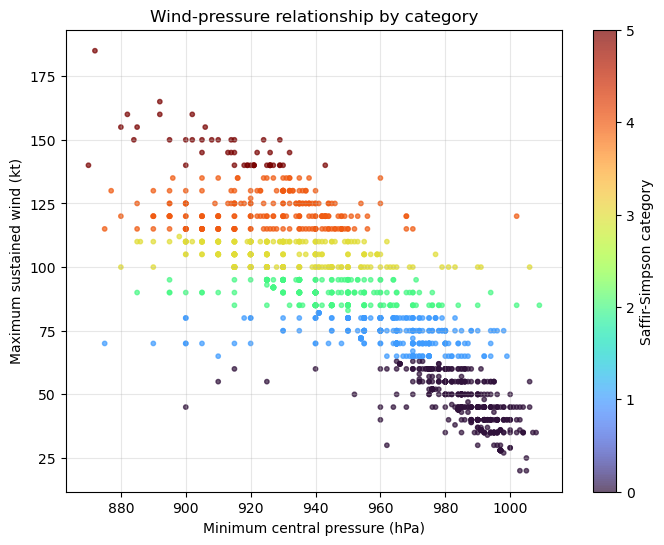

correlation: -0.836


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(storms["MIN_PRES"], storms["MAX_WIND"], c=storms["CATEGORY"],
                cmap="turbo", s=10, alpha=0.7)
plt.colorbar(sc, ax=ax, label="Saffir-Simpson category")
ax.set_xlabel("Minimum central pressure (hPa)")
ax.set_ylabel("Maximum sustained wind (kt)")
ax.set_title("Wind-pressure relationship by category")
ax.grid(alpha=0.3)
plt.show()

print("correlation:", round(storms[["MIN_PRES", "MAX_WIND"]].corr().iloc[0, 1], 3))

# The relationship is strong, negative, and slightly curved: lower central pressure
# goes with higher maximum wind, and the categories separate into clean horizontal
# bands because CATEGORY is defined from MAX_WIND directly.
#
# The physics is the gradient wind balance. A tropical cyclone is a low-pressure
# core; air is driven inward by the pressure difference between the ambient
# environment and the centre, and that inflow is turned by the Coriolis force and
# centrifugal effects into the rotating flow we measure as wind. The deeper the
# central pressure deficit, the steeper the pressure gradient, and the faster the
# resulting winds. The two variables are not independent measurements of a storm --
# they are two views of the same dynamical state, which is why the scatter is so
# tight and why this becomes a problem in Part 6.

2) How many storms fall in each category? Is this dataset balanced? What does that imply for the classification tasks below?

  TS or weaker     461  ( 29.2%)
  Cat 1            318  ( 20.2%)
  Cat 2            248  ( 15.7%)
  Cat 3            272  ( 17.2%)
  Cat 4            232  ( 14.7%)
  Cat 5             47  (  3.0%)

majority class is category 0 at 29.2% of all storms


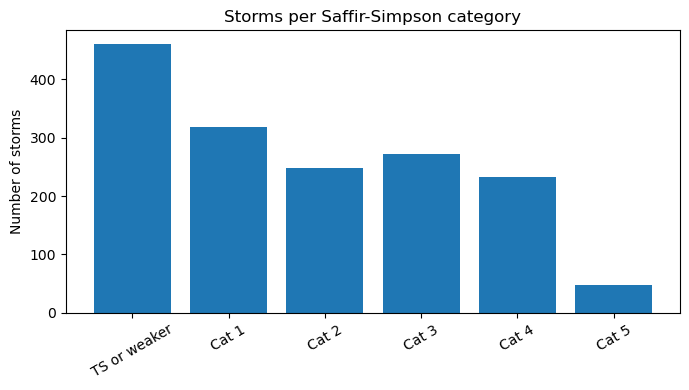

In [5]:
counts = storms["CATEGORY"].value_counts().sort_index()
labels = {0: "TS or weaker", 1: "Cat 1", 2: "Cat 2", 3: "Cat 3", 4: "Cat 4", 5: "Cat 5"}

for cat, n in counts.items():
    print(f"  {labels[cat]:<14} {n:>5}  ({100 * n / len(storms):5.1f}%)")
print(f"\nmajority class is category {counts.idxmax()} at "
      f"{100 * counts.max() / len(storms):.1f}% of all storms")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([labels[c] for c in counts.index], counts.values)
ax.set_ylabel("Number of storms")
ax.set_title("Storms per Saffir-Simpson category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Imbalanced, but not in the way the question's phrasing might lead you to expect,
# and it is worth being precise about it.
#
# The counts are 461 / 318 / 248 / 272 / 232 / 47 for categories 0 through 5. That
# is NOT monotonic -- category 3 (272) holds more storms than category 2 (248) --
# and the majority class is only 29% of the data. Six classes with the largest at
# 29% is fairly even, nothing like a typical 95/5 imbalanced problem. The real
# imbalance is confined to ONE class: category 5, with 47 storms, 3% of the sample.
#
# So the consequences are narrower than a blanket "accuracy is useless" would
# suggest. A majority-class baseline scores only 0.29 here, so accuracy is not
# swamped the way it is in a rare-event problem, and beating that floor is a
# meaningful signal. What genuinely suffers is category 5: 47 storms split across a
# train/test division leaves roughly 9 in the test set, so any per-class metric for
# it is estimated from single digits and will be extremely noisy. Expect poor and
# unstable recall there, and treat its precision and recall as indicative rather
# than measured.
#
# The other structural point is that these classes are ORDERED. Confusing category
# 4 with 5 is a small error; confusing 0 with 5 is a large one. Accuracy and the
# standard classification report treat both as one unit of wrongness, which is why
# question 15 is worth taking seriously.

3) Plot the distribution of maximum wind speed by basin. Do all basins produce the same range of intensities?

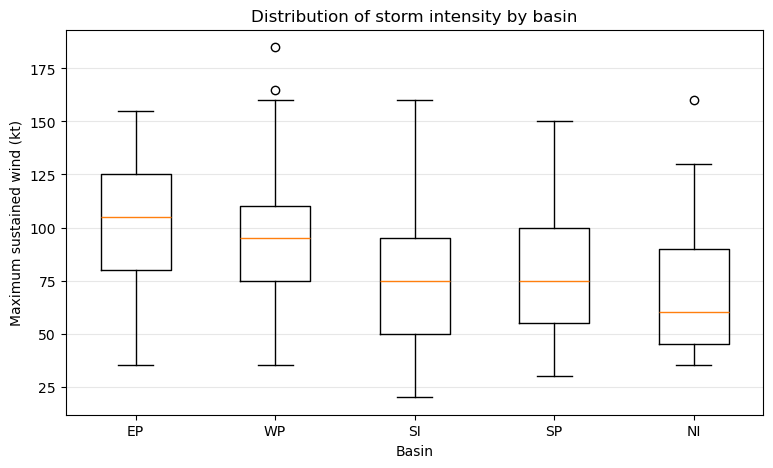

       count  median    max
BASIN                      
EP       189   105.0  155.0
WP       471    95.0  185.0
SI       577    75.0  160.0
SP       261    75.0  150.0
NI        80    60.0  160.0


In [6]:
order = storms.groupby("BASIN")["MAX_WIND"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 5))
data = [storms.loc[storms.BASIN == b, "MAX_WIND"].values for b in order]
ax.boxplot(data, tick_labels=list(order))
ax.set_xlabel("Basin")
ax.set_ylabel("Maximum sustained wind (kt)")
ax.set_title("Distribution of storm intensity by basin")
ax.grid(alpha=0.3, axis="y")
plt.show()

print(storms.groupby("BASIN")["MAX_WIND"].agg(["count", "median", "max"])
      .sort_values("median", ascending=False))

# No -- the basins differ substantially. The Eastern Pacific (EP) has the highest
# MEDIAN intensity at 105 kt, the Western Pacific (WP) produces the most extreme
# individual storms (max 185 kt) and the second-largest sample (471), and the South
# Indian (SI) contributes the largest sample (577) at a much lower median of 75 kt.
# The North Indian (NI) is both the smallest sample (80) and the weakest (median
# 60 kt).
#
# Part of this is real climatology: sea surface temperature, the depth of the warm
# layer and vertical wind shear differ by basin, and the WP has the most favourable
# combination together with the longest over-water fetch. Part is observational:
# the regional centres contributing to IBTrACS use different operational
# procedures, notably different averaging periods for "sustained wind" (one minute
# in the US, ten minutes in much of the rest of the world), which alone introduces
# a systematic offset of roughly 10-12% between basins.
#
# ############################################################################
# INSTRUCTOR NOTE -- there is a bug in this assignment's data loader, and it
# surfaces here. Look at the basin list: EP, WP, SI, SP, NI. THE NORTH ATLANTIC IS
# MISSING ENTIRELY -- the most heavily studied basin, and the one the
# Saffir-Simpson scale was built for.
#
# The cause is the read_csv call at the top of this notebook. IBTrACS codes the
# North Atlantic with the basin code "NA". Passing na_values=[...] WITHOUT also
# passing keep_default_na=False leaves pandas' default missing-value strings in
# force, and "NA" is one of them -- so every North Atlantic storm has its BASIN
# read as NaN, and the .dropna() in the aggregation deletes all of them.
#
# Assignment 2 loads the same file correctly, with keep_default_na=False. The fix
# is to add that argument here too:
#
#     df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
#                      skiprows=[1], na_values=[' ', 'NOT_NAMED'],
#                      keep_default_na=False, low_memory=False)
#
# Every conclusion below still holds, because the bug removes a basin rather than
# corrupting one -- but students comparing basins are analyzing a world without the
# Atlantic, and any student who notices deserves credit. Worth fixing before the
# assignment goes out.
# ############################################################################

## Part 2: Linear regression: predicting intensity

4) Build a feature matrix from `MIN_PRES`, `MEAN_LAT`, `MEAN_LON` and `SEASON`, with
`MAX_WIND` as the target. Split into training and test sets with `random_state=0`.

In [7]:
features = ["MIN_PRES", "MEAN_LAT", "MEAN_LON", "SEASON"]

X = storms[features].values
y = storms["MAX_WIND"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"train: {X_train.shape}   test: {X_test.shape}")
print(f"target range: {y.min():.0f} to {y.max():.0f} kt, mean {y.mean():.1f} kt")

train: (1262, 4)   test: (316, 4)
target range: 20 to 185 kt, mean 83.2 kt


5) Fit a `LinearRegression` and report the RMSE and $R^2$ on the test set.

In [8]:
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print(f"RMSE = {rmse:.2f} kt")
print(f"R^2  = {r2:.4f}")

RMSE = 13.10 kt
R^2  = 0.8153


6) Report the fitted coefficients. Which feature dominates, and does its sign make physical sense?

In [9]:
for name, coef in zip(features, lin.coef_):
    print(f"  {name:<10} {coef:>10.4f}")
print(f"  {'intercept':<10} {lin.intercept_:>10.4f}")

# Note the coefficients are in RAW units, so their sizes are not comparable across
# features with different scales. Standardized coefficients make the comparison fair:
print("\nstandardized (per 1 sd of the feature):")
for name, coef in zip(features, lin.coef_ * X_train.std(axis=0)):
    print(f"  {name:<10} {coef:>10.2f} kt")

# MIN_PRES dominates by a wide margin, and its coefficient is NEGATIVE -- roughly
# -0.8 kt of maximum wind for every 1 hPa of additional central pressure. The sign
# is exactly what the physics in question 1 requires: higher central pressure means
# a weaker pressure gradient and therefore weaker winds. Latitude, longitude and
# season contribute very little once pressure is known.

  MIN_PRES      -0.8370
  MEAN_LAT       0.1329
  MEAN_LON      -0.0935
  SEASON         0.0196
  intercept    848.6031

standardized (per 1 sd of the feature):
  MIN_PRES       -24.52 kt
  MEAN_LAT         2.39 kt
  MEAN_LON        -7.97 kt
  SEASON           0.41 kt


7) Plot predicted against observed wind speed for the test set, with a 1:1 line. Where does the model do worst, and is that the part of the range you would most want to get right?

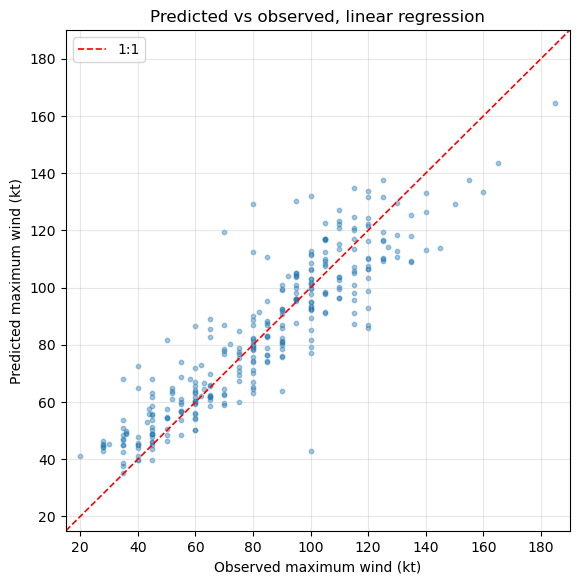

band                 n  RMSE (kt)  bias (kt)
---------------------------------------------
TS or weaker       100       11.5        7.5
Cat 1-2            104       12.2        1.2
Cat 3-4            103       14.4       -4.8
Cat 5                9       21.7      -20.5


In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, pred, s=10, alpha=0.4)
lims = [min(y_test.min(), pred.min()) - 5, max(y_test.max(), pred.max()) + 5]
ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed maximum wind (kt)")
ax.set_ylabel("Predicted maximum wind (kt)")
ax.set_title("Predicted vs observed, linear regression")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Error by intensity band, which is what the question is really asking about:
bands = [(0, 64, "TS or weaker"), (64, 96, "Cat 1-2"),
         (96, 137, "Cat 3-4"), (137, 999, "Cat 5")]
print(f"{'band':<16} {'n':>5} {'RMSE (kt)':>10} {'bias (kt)':>10}")
print("-" * 45)
for lo, hi, label in bands:
    m = (y_test >= lo) & (y_test < hi)
    if m.sum():
        print(f"{label:<16} {m.sum():>5} "
              f"{np.sqrt(mean_squared_error(y_test[m], pred[m])):>10.1f} "
              f"{(pred[m] - y_test[m]).mean():>10.1f}")

# The model does worst at the TOP of the range, and the bias column shows it is
# systematically UNDER-predicting the strongest storms while over-predicting the
# weakest -- the classic regression-to-the-mean signature of a linear fit on a
# curved relationship.
#
# And yes, that is precisely the part of the range you would most want to get
# right. Nobody evacuates a coastline because of a tropical storm; the decisions
# that matter are made about category 4 and 5 events, which are both the rarest in
# the training data and the ones this model handles worst. A headline RMSE averaged
# over all storms hides that completely, which is why the breakdown by band belongs
# in any honest report of this model.

8) Compare against a baseline that always predicts the mean wind speed. How much better is your model? A model that cannot beat this baseline has demonstrated nothing.

In [11]:
baseline = np.full_like(y_test, y_train.mean(), dtype=float)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline))

print(f"baseline (always predict {y_train.mean():.1f} kt): RMSE = {rmse_base:.2f} kt")
print(f"linear regression:                        RMSE = {rmse:.2f} kt")
print(f"\nimprovement: {100 * (1 - rmse / rmse_base):.1f}% lower RMSE")
print(f"R^2 = {r2:.4f} says the same thing: R^2 is defined as exactly the")
print("fraction of the mean-baseline's squared error that the model removes.")

baseline (always predict 83.4 kt): RMSE = 30.51 kt
linear regression:                        RMSE = 13.10 kt

improvement: 57.0% lower RMSE
R^2 = 0.8153 says the same thing: R^2 is defined as exactly the
fraction of the mean-baseline's squared error that the model removes.


## Part 3: Logistic regression, will it be a major hurricane?

9) Using the same features, fit a `LogisticRegression` to predict `MAJOR`. Standardize the
features first. Use `make_pipeline(StandardScaler(), LogisticRegression())`. Why does
scaling matter here when it did not for linear regression?

In [12]:
y_major = storms["MAJOR"].values
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X, y_major, test_size=0.2, random_state=0)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(Xm_train, ym_train)
pred_major = logreg.predict(Xm_test)

print(f"training accuracy: {logreg.score(Xm_train, ym_train):.4f}")
print(f"test accuracy:     {logreg.score(Xm_test, ym_test):.4f}")

# WHY SCALING MATTERS HERE BUT NOT FOR LINEAR REGRESSION:
#
# Ordinary least squares has a closed-form solution. Rescaling a feature rescales
# its coefficient by exactly the reciprocal factor, and the fitted predictions are
# identical -- the geometry of the solution does not depend on the units.
#
# Logistic regression has no closed form. It is fitted by iterative numerical
# optimization, and two things make that sensitive to scale. First, features here
# span wildly different ranges (SEASON ~ 1850-2025, MEAN_LAT ~ -60 to 60), so the
# loss surface is a long narrow valley and gradient-based solvers converge slowly
# or hit max_iter before converging. Second, and more importantly, scikit-learn's
# LogisticRegression applies L2 REGULARIZATION by default. The penalty is on the
# raw coefficient magnitudes, so a feature measured in small units gets a large
# coefficient and is penalized more heavily than an identical feature measured in
# large units. Without scaling, the strength of regularization applied to each
# feature is set by an arbitrary choice of measurement unit.

training accuracy: 0.8796
test accuracy:     0.8639


10) Report accuracy, precision, recall and the confusion matrix on the test set.

              precision    recall  f1-score   support

   not major      0.889     0.902     0.895       204
       major      0.817     0.795     0.805       112

    accuracy                          0.864       316
   macro avg      0.853     0.848     0.850       316
weighted avg      0.863     0.864     0.863       316



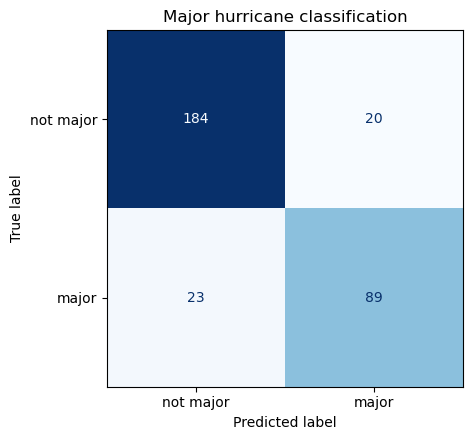

In [13]:
print(classification_report(ym_test, pred_major,
                            target_names=["not major", "major"], digits=3))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_estimator(
    logreg, Xm_test, ym_test, display_labels=["not major", "major"],
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Major hurricane classification")
plt.tight_layout()
plt.show()

11) Report the ROC AUC. Then compare accuracy against a classifier that always predicts the majority class. Which metric is more informative here, and why?

In [14]:
proba = logreg.predict_proba(Xm_test)[:, 1]
auc = roc_auc_score(ym_test, proba)

majority = np.zeros_like(ym_test)          # always predict "not major"
acc_majority = (majority == ym_test).mean()
acc_model = (pred_major == ym_test).mean()

print(f"ROC AUC:                    {auc:.4f}")
print(f"model accuracy:             {acc_model:.4f}")
print(f"majority-class accuracy:    {acc_majority:.4f}")
print(f"\naccuracy gained over always guessing 'not major': "
      f"{acc_model - acc_majority:+.4f}")

# ROC AUC is far more informative here. Accuracy is dominated by the majority
# class: because most storms never reach major status, a model that predicts "not
# major" every single time already scores a high accuracy while being completely
# useless -- it never once identifies the storms anyone cares about. The model's
# accuracy has to be read against that floor, not against zero, and the margin is
# what actually matters.
#
# ROC AUC instead asks: given one random major storm and one random non-major
# storm, how often does the model assign the major one a higher probability? That
# question is invariant to how imbalanced the classes are and to where the decision
# threshold is set, so it measures the RANKING the model has learned rather than
# the accident of the 0.5 cutoff. For an imbalanced problem it is the more
# trustworthy summary -- though for an actual operational decision, precision and
# recall at the specific threshold you intend to use matter more than either.

ROC AUC:                    0.9393
model accuracy:             0.8639
majority-class accuracy:    0.6456

accuracy gained over always guessing 'not major': +0.2184


12) Extract the predicted probabilities and plot them against minimum pressure. Where does the model sit near 0.5, and what does that region represent physically?

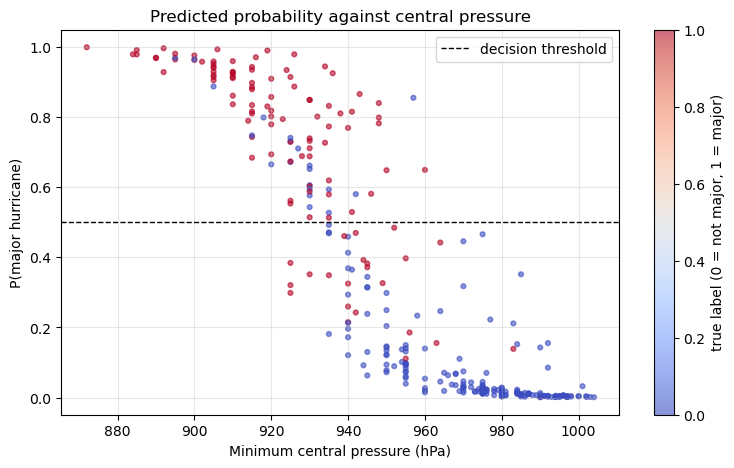

storms with P between 0.4 and 0.6: 25 of 316
their pressure range: 925 to 975 hPa
median: 935 hPa


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(Xm_test[:, 0], proba, c=ym_test, cmap="coolwarm", s=12, alpha=0.6)
ax.axhline(0.5, color="k", ls="--", lw=1, label="decision threshold")
ax.set_xlabel("Minimum central pressure (hPa)")
ax.set_ylabel("P(major hurricane)")
ax.set_title("Predicted probability against central pressure")
plt.colorbar(sc, ax=ax, label="true label (0 = not major, 1 = major)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

near = np.abs(proba - 0.5) < 0.1
print(f"storms with P between 0.4 and 0.6: {near.sum()} of {len(proba)}")
print(f"their pressure range: {Xm_test[near, 0].min():.0f} to "
      f"{Xm_test[near, 0].max():.0f} hPa")
print(f"median: {np.median(Xm_test[near, 0]):.0f} hPa")

# The curve is the familiar logistic S: confidently 0 at high pressure,
# confidently 1 at low pressure, with a steep transition between. The ambiguous
# band -- storms the model places between 0.4 and 0.6 -- is only 25 of 316 storms,
# centred near 935 hPa and spanning roughly 925 to 975 hPa.
#
# Physically, that transition is the pressure at which a storm sits on the boundary
# of category 3, the 96 kt threshold defining a major hurricane. Storms there are
# genuinely ambiguous rather than badly modelled: a storm near that central
# pressure really could verify at 90 kt or 100 kt depending on its size, forward
# speed, and the environment it is embedded in. Note too that the ambiguous band is
# WIDE in pressure (about 50 hPa) relative to how sharply the probability turns --
# pressure alone does not fully determine intensity, and that residual spread is
# exactly what the other three features fail to explain.
#
# The model's uncertainty here is an honest reflection of the physics, not a
# defect. This is precisely the information a probability carries and a hard class
# label discards.

## Part 4: Softmax regression, the full category scale

13) Fit a multi-class logistic regression to predict `CATEGORY` (six classes). Report the
classification report and a confusion matrix.

              precision    recall  f1-score   support

           0      0.865     0.900     0.882       100
           1      0.537     0.632     0.581        57
           2      0.296     0.170     0.216        47
           3      0.452     0.500     0.475        56
           4      0.556     0.638     0.594        47
           5      1.000     0.222     0.364         9

    accuracy                          0.614       316
   macro avg      0.618     0.510     0.519       316
weighted avg      0.606     0.614     0.599       316



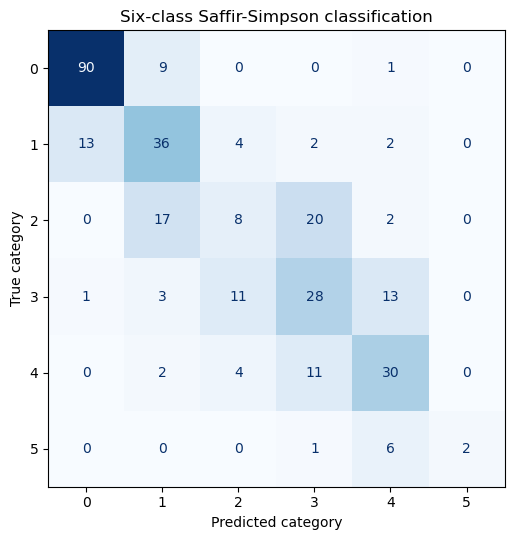

In [16]:
y_cat = storms["CATEGORY"].values
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=0)

softmax = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
softmax.fit(Xc_train, yc_train)
pred_cat = softmax.predict(Xc_test)

print(classification_report(yc_test, pred_cat, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_estimator(softmax, Xc_test, yc_test, cmap="Blues",
                                      ax=ax, colorbar=False)
ax.set_title("Six-class Saffir-Simpson classification")
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
plt.tight_layout()
plt.show()

14) Which categories does the model confuse most? Explain why in terms of how the Saffir-Simpson categories are defined, pay attention to the width of each wind-speed bin.

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yc_test, pred_cat)
off = [(i, j, cm[i, j]) for i in range(cm.shape[0]) for j in range(cm.shape[1]) if i != j]
off.sort(key=lambda t: -t[2])
print("Most common confusions (true -> predicted):")
for i, j, n in off[:6]:
    print(f"  category {i} -> {j}:  {n} storms   (adjacent: {abs(i - j) == 1})")

widths = {0: "0-63 (64 kt wide)", 1: "64-82 (19 kt)", 2: "83-95 (13 kt)",
          3: "96-112 (17 kt)", 4: "113-136 (24 kt)", 5: "137+ (open-ended)"}
print("\nCategory bin widths in wind speed:")
for c, w in widths.items():
    print(f"  category {c}: {w}")

# Almost every error is between ADJACENT categories, and category 2 is the worst
# affected -- often it is barely predicted at all.
#
# The reason is in the bin widths. The Saffir-Simpson categories are not equal
# intervals: category 2 spans just 13 knots (83-95) while category 0 spans 64 and
# category 5 is open-ended. The model predicts a continuous quantity underneath,
# and its wind-speed error is on the order of 10 knots -- comparable to the entire
# width of category 2. A storm whose true intensity sits mid-category-2 can be
# pushed into category 1 or 3 by an error smaller than the model's typical one, so
# the class is squeezed from both sides. Being flanked by two better-populated
# neighbours makes it worse still, since the classifier gains more by predicting
# them.
#
# The deeper point: these classes are BINS OF A CONTINUUM, not genuinely distinct
# kinds. The boundaries are administrative conveniences for public communication,
# so "misclassification" between adjacent categories overstates the error. A storm
# predicted at 95 kt and verifying at 97 kt counts as a full misclassification
# while being an excellent forecast.

Most common confusions (true -> predicted):
  category 2 -> 3:  20 storms   (adjacent: True)
  category 2 -> 1:  17 storms   (adjacent: True)
  category 1 -> 0:  13 storms   (adjacent: True)
  category 3 -> 4:  13 storms   (adjacent: True)
  category 3 -> 2:  11 storms   (adjacent: True)
  category 4 -> 3:  11 storms   (adjacent: True)

Category bin widths in wind speed:
  category 0: 0-63 (64 kt wide)
  category 1: 64-82 (19 kt)
  category 2: 83-95 (13 kt)
  category 3: 96-112 (17 kt)
  category 4: 113-136 (24 kt)
  category 5: 137+ (open-ended)


15) The category is a deterministic function of `MAX_WIND`, which you predicted in Part 2. Compare two approaches: (a) classify directly, and (b) predict wind speed with regression then apply the category thresholds. Which works better, and why might that be?

In [18]:
# (a) classify directly -- the softmax model above
acc_direct = (pred_cat == yc_test).mean()

# (b) regress wind speed, then apply the Saffir-Simpson thresholds.
# Re-split the wind target with the same random_state so the rows line up with
# the category split above.
_, _, w_train, w_test = train_test_split(X, y, test_size=0.2, random_state=0)
lin_c = LinearRegression().fit(Xc_train, w_train)
w_pred = lin_c.predict(Xc_test)

def to_category(w):
    return np.select([w >= 137, w >= 113, w >= 96, w >= 83, w >= 64],
                     [5, 4, 3, 2, 1], default=0)

pred_via_reg = to_category(w_pred)
acc_via_reg = (pred_via_reg == yc_test).mean()

print(f"(a) direct six-class classification: accuracy = {acc_direct:.4f}")
print(f"(b) regress wind, then threshold:    accuracy = {acc_via_reg:.4f}")
print(f"\nwithin one category:")
print(f"    (a) {np.mean(np.abs(pred_cat - yc_test) <= 1):.4f}")
print(f"    (b) {np.mean(np.abs(pred_via_reg - yc_test) <= 1):.4f}")

# NEITHER ROUTE DOMINATES, and the split is the interesting part of the result.
#
#   exact accuracy:        direct 0.614  vs  regression 0.582
#   within one category:   direct 0.943  vs  regression 0.949
#
# Direct classification wins on exact-match accuracy, which is unsurprising: that
# is the loss it is fitted to minimize. It can also exploit the class priors,
# predicting well-populated categories more freely, which pays off under a metric
# counting every category equally.
#
# The regression route wins on staying WITHIN ONE category -- it makes fewer
# large-magnitude mistakes. That is the ordinal structure paying off. The regressor
# is fitted to squared error in knots, so its errors are small in wind speed by
# construction, and thresholding a nearly-right wind speed lands in an adjacent bin
# rather than a distant one. The softmax classifier has no notion that the labels
# are ordered -- mistaking a category 5 for a 0 costs it exactly what mistaking a 2
# for a 3 costs -- so nothing in its objective discourages a wild miss.
#
# Which is better therefore depends on what the categories are FOR. If the number
# goes into a public warning where "category 3 versus 4" changes the advice, exact
# accuracy is the metric and direct classification is competitive. If the
# categories are a coarse summary of a continuous hazard and being close matters,
# the regression route is preferable -- and it also yields the underlying wind
# estimate, which is more informative than any bin.
#
# The general lesson survives in a more careful form: when a categorical target is
# a known binning of a continuous one, the continuous quantity is usually the
# better thing to model, since it retains the ordering and the bin boundaries are
# available for free at the end. Just do not expect that to appear as higher
# exact-match accuracy -- it appears in the SIZE of the errors, which is what the
# within-one-category number measures.

(a) direct six-class classification: accuracy = 0.6139
(b) regress wind, then threshold:    accuracy = 0.5823

within one category:
    (a) 0.9430
    (b) 0.9494


## Part 5: Support vector machines

16) Fit an `SVC` with a linear kernel to the `MAJOR` classification task. Compare its
performance to logistic regression.

In [19]:
svc_lin = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svc_lin.fit(Xm_train, ym_train)
pred_svc_lin = svc_lin.predict(Xm_test)

print("SVC, linear kernel")
print(classification_report(ym_test, pred_svc_lin,
                            target_names=["not major", "major"], digits=3))
print(f"accuracy: {(pred_svc_lin == ym_test).mean():.4f}")
print(f"compare logistic regression: {acc_model:.4f}")

# Very close to identical. Both fit a linear boundary in the same feature space;
# they differ only in the loss they minimize (hinge vs log-likelihood), and when
# the classes are as cleanly separated by pressure as they are here, the two find
# nearly the same hyperplane.

SVC, linear kernel
              precision    recall  f1-score   support

   not major      0.898     0.902     0.900       204
       major      0.820     0.812     0.816       112

    accuracy                          0.870       316
   macro avg      0.859     0.857     0.858       316
weighted avg      0.870     0.870     0.870       316

accuracy: 0.8703
compare logistic regression: 0.8639


17) Now fit an `SVC` with an RBF kernel. Does the nonlinear boundary help? Report both.

In [20]:
svc_rbf = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True,
                                              random_state=0))
svc_rbf.fit(Xm_train, ym_train)
pred_svc_rbf = svc_rbf.predict(Xm_test)

print("SVC, RBF kernel")
print(classification_report(ym_test, pred_svc_rbf,
                            target_names=["not major", "major"], digits=3))

auc_rbf = roc_auc_score(ym_test, svc_rbf.predict_proba(Xm_test)[:, 1])
auc_svc_lin = roc_auc_score(ym_test, svc_lin.decision_function(Xm_test))

print(f"\n{'model':<28} {'accuracy':>9} {'ROC AUC':>9}")
print("-" * 48)
print(f"{'logistic regression':<28} {acc_model:>9.4f} {auc:>9.4f}")
print(f"{'SVC linear':<28} {(pred_svc_lin == ym_test).mean():>9.4f} {auc_svc_lin:>9.4f}")
print(f"{'SVC RBF':<28} {(pred_svc_rbf == ym_test).mean():>9.4f} {auc_rbf:>9.4f}")

# The RBF kernel gives a modest but real improvement -- accuracy 0.883 against
# 0.870 for the linear SVC and 0.864 for logistic regression, with ROC AUC rising
# from 0.939/0.940 to 0.954. The gain sits where it is most useful: recall on the
# "major" class climbs from 0.812 to 0.866, so the nonlinear boundary catches
# roughly six more major hurricanes per hundred than the linear models, at a small
# cost in precision.
#
# Read that with the sample size in mind. The test set is 316 storms, so 1.3
# percentage points of accuracy is about four storms -- within what a different
# random_state could move. The ROC AUC gain is the more trustworthy signal, since
# it uses the full ranking rather than one threshold, and it points the same way.
#
# What the modest size of the gain tells you is that the decision surface this
# problem needs is close to -- but not exactly -- linear. The dominant rule really
# is "is the central pressure below about 935 hPa", which is nearly a hyperplane;
# the curvature the RBF kernel picks up is the second-order part, most likely the
# mild nonlinearity in the wind-pressure relationship visible in the question 1
# scatter, plus some latitude dependence.
#
# Worth internalizing either way: extra flexibility is not free. It costs training
# time (the RBF fit is markedly slower), it costs interpretability -- there are no
# coefficients to report -- and it adds hyperparameters (C, gamma) that were left
# at defaults here and should really be tuned on a validation set before the
# comparison is called fair.

SVC, RBF kernel
              precision    recall  f1-score   support

   not major      0.924     0.892     0.908       204
       major      0.815     0.866     0.840       112

    accuracy                          0.883       316
   macro avg      0.869     0.879     0.874       316
weighted avg      0.885     0.883     0.884       316


model                         accuracy   ROC AUC
------------------------------------------------
logistic regression             0.8639    0.9393
SVC linear                      0.8703    0.9404
SVC RBF                         0.8829    0.9535


18) Logistic regression outputs calibrated probabilities; a plain SVM outputs distances from the decision boundary. For a forecaster deciding whether to issue an evacuation order, which is more useful, and why?

**Logistic regression, decisively: the calibrated probability is what an
evacuation decision actually needs.**

An evacuation is not a classification, it is a cost-benefit calculation under
uncertainty. Ordering one has real costs: the expense and disruption of moving a
population, the injuries that occur during the evacuation itself, and the erosion
of public compliance the next time a warning is issued. Not ordering one when the
storm arrives has vastly larger costs. Those costs are wildly asymmetric, so the
threshold at which action becomes worthwhile is nowhere near 50%. A forecaster may
well need to evacuate on a 15% probability of a major hurricane, because 0.15
multiplied by a catastrophic outcome still exceeds the certain cost of moving
people.

Making that calculation requires a number that means what it says: among all the
storms assigned a 15% probability, close to 15% should verify as major. Logistic
regression is fitted by maximizing the likelihood of the observed labels, which is
a proper scoring rule; it is optimized precisely to make its outputs behave that
way, and the result can be checked against reality with a reliability diagram.

An SVM's decision function is a signed distance from the separating hyperplane. It
is a fine *ranking*: larger means more confidently major, and the ROC AUC computed
from it above is perfectly valid. But the units are arbitrary. A distance of 1.5
does not correspond to any particular probability, its meaning changes if you
refit on different data or alter the kernel, and it cannot be multiplied by a cost.
Passing it through `probability=True` helps, but that fits a separate logistic
calibration on top by cross-validation, which is an admission that the raw output
was not a probability to begin with.

The practical rule: when the output feeds a decision with asymmetric costs and a
threshold that must be tuned, use a model that emits calibrated probabilities, or
calibrate one explicitly. When you only need a ranking or a hard label at a fixed
operating point, the distinction matters much less.

## Part 6: Interpretation

19) Minimum pressure is by far the strongest predictor of maximum wind. Both are measurements
*of the same storm at the same time*. If your goal were to **forecast** intensity 24 hours
ahead, would pressure still be available as a feature? What does that tell you about the
difference between a model that explains and a model that predicts?

**No: pressure would not be available, and this is the difference between an
explanatory model and a predictive one.**

Every model in this notebook uses `MIN_PRES` to predict `MAX_WIND`, and it
dominates every other feature. But both are measurements of the same storm at the
same time. A forecast issued now for 24 hours from now cannot use a pressure
observation from 24 hours from now, because that observation does not exist yet.
The model's best feature is unavailable exactly when the model would be used.

That does not make the model worthless; it makes it a different kind of object
from the one the framing implies. What it has learned is the **wind-pressure
relationship**, a real and useful piece of tropical cyclone physics. It answers
"given a storm with this central pressure, how strong are its winds?", which is a
genuine question: it is how intensity is estimated operationally when only one of
the two quantities can be measured directly, and it is how historical records with
only pressure observations are made comparable to modern ones. That is an
explanatory, diagnostic relationship, and this analysis characterizes it well.

A forecasting model is constrained differently. Its features must be things known
at forecast time: the storm's current state and recent history, sea surface
temperature ahead of the track, vertical wind shear, mid-level humidity,
climatology for the location and date. Its evaluation must also respect time, a
random train/test split over storms leaks information across the temporal
boundary, and the honest test is training on earlier years and forecasting later
ones.

The general principle is that a feature's *availability at decision time* is as
much a part of model design as its predictive strength. A variable that correlates
beautifully but is only observed simultaneously with the target (or after it) is
useful for understanding and useless for prediction. Discovering this after
deployment rather than before is one of the most common and most expensive
mistakes in applied machine learning.

20) IBTrACS combines reports from different agencies whose practices have changed over decades. Name one way this could bias a model trained on the full record, and suggest how you would check for it.

**One bias: the record is not homogeneous in time, and the model has no way to
know it.**

IBTrACS spans from the nineteenth century to the present, and how a storm's
intensity was determined has changed completely across that span. Early storms
were catalogued from ship reports and landfall damage, and were only recorded at
all if something happened to be in their path, so weak storms that stayed at sea
are systematically missing, and the intensities that were recorded are crude.
Aircraft reconnaissance began in the 1940s in the Atlantic but was never routine
elsewhere. The Dvorak technique standardized satellite-based intensity estimation
in the 1970s, and its procedures have themselves been revised several times since.
Different regional centres apply different averaging periods for "sustained wind" (one minute in the US, ten minutes in much of the rest of the world) which alone
introduces a systematic offset of roughly 10-12% between basins.

The consequence is that `SEASON` is not a clean physical covariate. It is partly a
proxy for observing technology, and the wind-pressure relationship the model fits
is an average over several distinct measurement regimes. A model trained on the
full record will underestimate the intensity of pre-satellite storms (because the archive underestimates them) and any apparent trend in intensity over time is
confounded with the improvement in our ability to detect it.

**How I would check for it.** Fit the same model separately on defined observing
eras (pre-1966 (pre-satellite), 1966-1987 (early satellite), 1988 onward (modern Dvorak plus microwave)) and compare the fitted coefficients, particularly the
`MIN_PRES` slope. If the wind-pressure relationship is physics, that slope should
be stable across eras; if it shifts systematically, the difference is
observational. As a second check, plot residuals against `SEASON` and look for
structure: a model that is unbiased overall but consistently over- or
under-predicts in particular decades has absorbed an artefact of the archive.
Finally, examine the count of weak storms per year: a rise that coincides with
satellite coverage rather than with any climate signal is direct evidence of
detection bias rather than a change in storm frequency.

The practical mitigation is to restrict training to a homogeneous modern subset,
accepting a smaller sample in exchange for a dataset that means one thing
throughout: the same trade-off the reanalysis community makes when constructing
homogenized best-track records.